In [ ]:
# CELDA 1: SETUP + MODELOS

import sys
import subprocess
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("⏳ Configurando entorno...\n")

packages = [
    "open-clip-torch==2.23.0",
    "transformers==4.35.2",
    "scikit-learn",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
    print(f"✅ {pkg}")

# Importar módulos
from utils.model_factory import create_model, list_available_models
from utils.embeddings import get_all_patch_embeddings_from_image
from utils.multi_step_clustering import (
    run_block_clustering_on_embeddings,
    decidir_fondo_vs_tejido,
    decidir_nucleos_vs_citoplasma
)
from utils.visualization import visualizar_clusters_basicos
from utils.coco_loader import list_coco_images, load_image_and_segmentations_from_coco

print("\nModelos disponibles:")
for name, desc in list_available_models().items():
    print(f"  - {name}: {desc}")

# Cargar ambos modelos
print("\n🔬 Cargando BiomedCLIP...")
model_biomedclip = create_model('biomedclip')

print("🔬 Cargando UNI...")
model_uni = create_model('uni')

print("\n✅ Setup completado")

In [ ]:
# CELDA 2: CARGAR IMAGEN Y GROUND TRUTH

JSON_PATH = r"C:\Users\mngra\projects\AI\Pap\PAP_DATA\CCEDD\CCEDD-UTN-10imgs\train\_annotations.coco.json"
IMAGES_DIR = r"C:\Users\mngra\projects\AI\Pap\PAP_DATA\CCEDD\CCEDD-UTN-10imgs\train"

print("📂 Explorando dataset...")
images_list = list_coco_images(JSON_PATH)
print(f"Imágenes disponibles: {len(images_list)}")

IMAGE_INDEX = 0
CATEGORY_IDS = [4, 5]  # kernel y kernel-not-confirmed

print(f"\n📷 Cargando imagen {IMAGE_INDEX}...")
img_original, segmentations, fname, (H_orig, W_orig) = load_image_and_segmentations_from_coco(
    JSON_PATH, IMAGES_DIR,
    image_id=images_list[IMAGE_INDEX]["id"],
    block_size=224,
    category_ids=CATEGORY_IDS
)

# Resize
TARGET_SIZE =  img_original.shape# (1376, 1020)
scale = min(TARGET_SIZE[0] / img_original.shape[1], TARGET_SIZE[1] / img_original.shape[0])
new_w = int(img_original.shape[1] * scale)
new_h = int(img_original.shape[0] * scale)
img_resized = cv2.resize(img_original, (new_w, new_h), interpolation=cv2.INTER_AREA)

# Escalar segmentations
segmentations_scaled = []
for seg in segmentations:
    scaled_coords = [[int(x * scale), int(y * scale)] for x, y in seg['polygon_coords']]
    segmentations_scaled.append({
        'category_id': seg['category_id'],
        'polygon_coords': scaled_coords,
        'annotation_id': seg.get('annotation_id', None)
    })
segmentations = segmentations_scaled

# Convertir a grises
if img_resized.ndim == 3:
    img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
else:
    img = img_resized

H, W = img.shape[:2]
print(f"✅ {fname}")
print(f"   Dimensiones: {W}x{H}")
print(f"   Núcleos GT: {len(segmentations)}")

# Visualizar
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(img, cmap='gray')
for i, seg in enumerate(segmentations):
    polygon = np.array(seg['polygon_coords'], dtype=np.int32)
    if len(polygon) >= 3:
        ax.plot(np.append(polygon[:, 0], polygon[0, 0]),
                np.append(polygon[:, 1], polygon[0, 1]),
                'b-', linewidth=2, label='GT' if i == 0 else '')
ax.set_title(f"Imagen + GT ({len(segmentations)} núcleos)", fontweight='bold')
ax.axis('off')
if len(segmentations) > 0:
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# CELDA 3: PASO 1 - BIOMEDCLIP (FONDO VS CONTENIDO)

print("\n" + "="*60)
print("PASO 1: BiomedCLIP - Fondo vs Contenido")
print("="*60)

print("\n🔬 Extrayendo embeddings con BiomedCLIP...")
patch_data_biomedclip = get_all_patch_embeddings_from_image(
    img_resized, model_biomedclip,
    preprocess=None,
    tile_size=224
)

print(f"✅ {len(patch_data_biomedclip)} patches extraídos")


print("\n🔬 Extrayendo embeddings con UNI...")
patch_data_uni = get_all_patch_embeddings_from_image(
    img_resized, model_uni,
    preprocess=None,
    tile_size=224
)

print(f"✅ {len(patch_data_uni)} patches extraídos")

print("\n🎯 Clustering k=2 (fondo vs contenido)...")
clustered_k2 = run_block_clustering_on_embeddings(patch_data_biomedclip, n_clusters=2)
fondo_id, tejido_id, stats = decidir_fondo_vs_tejido(img, clustered_k2)

print(f"\n📊 Resultados:")
print(f"   Cluster fondo: {fondo_id}")
print(f"   Cluster tejido: {tejido_id}")
print(f"   Stats: {stats}")

# Convertir boxes GT a formato compatible (usar polígonos como aproximación)
boxes = []
for seg in segmentations:
    coords = np.array(seg['polygon_coords'])
    if len(coords) >= 3:
        x_min, y_min = coords.min(axis=0)
        x_max, y_max = coords.max(axis=0)
        boxes.append((seg['category_id'], x_min, y_min, x_max, y_max))

visualizar_clusters_basicos(img, clustered_k2, boxes=boxes, title="Paso 1: BiomedCLIP - Fondo vs Tejido")

print("\n✅ Paso 1 completado")

In [ ]:
# CELDA 4: BÚSQUEDA DE NÚCLEOS POR SIMILITUD

import random
from scipy.spatial.distance import cdist
from shapely.geometry import Point, Polygon as ShapelyPolygon

def get_embedding_for_polygon(polygon_coords, patch_data, img_shape):
    """
    Calcula el embedding promedio de los patches que intersectan con un polígono.
    """
    H, W = img_shape[:2]
    poly = ShapelyPolygon(polygon_coords)
    
    embeddings_in_polygon = []
    for patch in patch_data:
        # position es una tupla (x1, y1, x2, y2)
        x1, y1, x2, y2 = patch['position']
        w, h = x2 - x1, y2 - y1
        # Centro del patch
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        point = Point(cx, cy)
        
        if poly.contains(point) or poly.intersects(Point(cx, cy).buffer(min(w, h)/4)):
            embeddings_in_polygon.append(patch['embedding'])
    
    if len(embeddings_in_polygon) == 0:
        return None
    
    return np.mean(embeddings_in_polygon, axis=0)


def buscar_similares(embedding_query, patch_data, threshold, metric='cosine'):
    """
    Busca patches con embeddings similares al query, usando un threshold.
    Retorna lista de índices de patches similares.
    """
    # Extraer todos los embeddings
    all_embeddings = np.array([p['embedding'] for p in patch_data])
    
    # Calcular distancias
    distances = cdist([embedding_query], all_embeddings, metric=metric)[0]
    
    # Filtrar por threshold
    similar_indices = np.where(distances <= threshold)[0]
    
    return similar_indices, distances[similar_indices]


def visualizar_busqueda(img, patch_data, query_polygons, found_patches, title="Búsqueda de núcleos"):
    """
    Visualiza los polígonos query y los patches encontrados.
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(img, cmap='gray')
    
    # Dibujar polígonos query (prototipos) en verde
    for i, seg in enumerate(query_polygons):
        polygon = np.array(seg['polygon_coords'], dtype=np.int32)
        if len(polygon) >= 3:
            ax.plot(np.append(polygon[:, 0], polygon[0, 0]),
                    np.append(polygon[:, 1], polygon[0, 1]),
                    'g-', linewidth=3, label='Prototipos' if i == 0 else '')
    
    # Dibujar patches encontrados en rojo
    for i, idx in enumerate(found_patches):
        patch = patch_data[idx]
        x1, y1, x2, y2 = patch['position']
        w, h = x2 - x1, y2 - y1
        rect = Rectangle((x1, y1), w, h,
                         linewidth=1.5, edgecolor='red', facecolor='none',
                         label='Encontrados' if i == 0 else '')
        ax.add_patch(rect)
    
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.axis('off')
    ax.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()


def calcular_metricas_deteccion(found_patches, patch_data, gt_segmentations, img_shape, iou_threshold=0.3):
    """
    Calcula precisión y recall de la detección.
    """
    # Convertir patches encontrados a polígonos
    found_boxes = []
    for idx in found_patches:
        p = patch_data[idx]
        x1, y1, x2, y2 = p['position']
        found_boxes.append(ShapelyPolygon([
            [x1, y1], [x2, y1], [x2, y2], [x1, y2]
        ]))
    
    # GT polígonos
    gt_polygons = [ShapelyPolygon(seg['polygon_coords']) for seg in gt_segmentations]
    
    # Calcular matches
    tp = 0  # True positives
    matched_gt = set()
    
    for found_box in found_boxes:
        for i, gt_poly in enumerate(gt_polygons):
            if i in matched_gt:
                continue
            intersection = found_box.intersection(gt_poly).area
            union = found_box.union(gt_poly).area
            iou = intersection / union if union > 0 else 0
            
            if iou >= iou_threshold:
                tp += 1
                matched_gt.add(i)
                break
    
    fp = len(found_boxes) - tp  # False positives
    fn = len(gt_polygons) - tp  # False negatives
    
    precision = tp / len(found_boxes) if len(found_boxes) > 0 else 0
    recall = tp / len(gt_polygons) if len(gt_polygons) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'f1': f1,
        'total_found': len(found_boxes), 'total_gt': len(gt_polygons)
    }


# ========== PARÁMETROS ==========
N_PROTOTIPOS = 5  # Número de núcleos aleatorios a usar como prototipos
MODEL_TO_USE = 'uni'  # 'uni' o 'biomedclip'
THRESHOLDS = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]  # Thresholds más bajos para distancia coseno
USE_INDIVIDUAL_PROTOTYPES = False  # Si True, usa OR entre prototipos; si False, usa promedio

print("="*70)
print("🔍 BÚSQUEDA DE NÚCLEOS POR SIMILITUD DE EMBEDDINGS")
print("="*70)

# Seleccionar patch_data según el modelo
patch_data_to_use = patch_data_uni if MODEL_TO_USE == 'uni' else patch_data_biomedclip
print(f"\n📊 Usando modelo: {MODEL_TO_USE.upper()}")
print(f"📊 Total de patches: {len(patch_data_to_use)}")
print(f"📊 Total de núcleos GT: {len(segmentations)}")

# Seleccionar n núcleos aleatorios como prototipos
random.seed(42)
n_prototipos = min(N_PROTOTIPOS, len(segmentations))
prototipos_indices = random.sample(range(len(segmentations)), n_prototipos)
prototipos = [segmentations[i] for i in prototipos_indices]

print(f"\n🎯 Seleccionados {n_prototipos} núcleos como prototipos")

# Calcular embeddings de los prototipos
embeddings_prototipos = []
for i, proto in enumerate(prototipos):
    emb = get_embedding_for_polygon(proto['polygon_coords'], patch_data_to_use, img.shape)
    if emb is not None:
        embeddings_prototipos.append(emb)
        print(f"   ✅ Prototipo {i+1}: embedding shape {emb.shape}")
    else:
        print(f"   ⚠️  Prototipo {i+1}: sin patches válidos")

print(f"\n✅ {len(embeddings_prototipos)} prototipos con embeddings válidos")

# Calcular embedding promedio de todos los prototipos
embedding_query = np.mean(embeddings_prototipos, axis=0)
print(f"📊 Embedding query (promedio): shape {embedding_query.shape}")

# Probar diferentes thresholds
print(f"\n{'='*70}")
print("🎯 PROBANDO DIFERENTES THRESHOLDS")
print(f"{'='*70}\n")

resultados = []

for threshold in THRESHOLDS:
    print(f"\n{'─'*70}")
    print(f"🔍 THRESHOLD = {threshold}")
    print(f"{'─'*70}")
    
    # Buscar patches similares
    found_indices, distances = buscar_similares(embedding_query, patch_data_to_use, threshold)
    
    print(f"   Patches encontrados: {len(found_indices)}")
    if len(found_indices) > 0:
        print(f"   Distancia mínima: {distances.min():.4f}")
        print(f"   Distancia máxima: {distances.max():.4f}")
        print(f"   Distancia promedio: {distances.mean():.4f}")
    
    # Calcular métricas
    if len(found_indices) > 0:
        metricas = calcular_metricas_deteccion(found_indices, patch_data_to_use, segmentations, img.shape)
        
        print(f"\n   📊 MÉTRICAS:")
        print(f"      TP: {metricas['tp']}, FP: {metricas['fp']}, FN: {metricas['fn']}")
        print(f"      Precision: {metricas['precision']:.3f}")
        print(f"      Recall: {metricas['recall']:.3f}")
        print(f"      F1-Score: {metricas['f1']:.3f}")
        
        resultados.append({
            'threshold': threshold,
            'n_found': len(found_indices),
            **metricas
        })
        
        # Visualizar
        visualizar_busqueda(img, patch_data_to_use, prototipos, found_indices,
                           title=f"Búsqueda con threshold={threshold} | F1={metricas['f1']:.3f} | Precision={metricas['precision']:.3f} | Recall={metricas['recall']:.3f}")
    else:
        print("   ⚠️  No se encontraron patches similares")
        resultados.append({
            'threshold': threshold,
            'n_found': 0,
            'precision': 0, 'recall': 0, 'f1': 0
        })

# Resumen de resultados
print(f"\n{'='*70}")
print("📊 RESUMEN DE RESULTADOS")
print(f"{'='*70}\n")

print(f"{'Threshold':<12} {'Encontrados':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("─" * 70)
for res in resultados:
    print(f"{res['threshold']:<12.2f} {res['n_found']:<12} {res['precision']:<12.3f} {res['recall']:<12.3f} {res['f1']:<12.3f}")

# Encontrar mejor threshold según F1
mejor_resultado = max(resultados, key=lambda x: x['f1'])
print(f"\n🏆 MEJOR THRESHOLD: {mejor_resultado['threshold']} (F1 = {mejor_resultado['f1']:.3f})")

# Gráfico de métricas vs threshold
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

thresholds_plot = [r['threshold'] for r in resultados]
precisions = [r['precision'] for r in resultados]
recalls = [r['recall'] for r in resultados]
f1s = [r['f1'] for r in resultados]

axes[0].plot(thresholds_plot, precisions, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision vs Threshold', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds_plot, recalls, 'o-', color='orange', linewidth=2, markersize=8)
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('Recall vs Threshold', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(thresholds_plot, f1s, 'o-', color='green', linewidth=2, markersize=8)
axes[2].axvline(mejor_resultado['threshold'], color='red', linestyle='--', label=f"Mejor: {mejor_resultado['threshold']}")
axes[2].set_xlabel('Threshold', fontsize=12)
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_title('F1-Score vs Threshold', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Análisis completado")


🔍 ANÁLISIS DE TAMAÑOS Y AGREGACIÓN ESPACIAL

📏 Tamaño actual de patch: 16x16 píxeles
📏 Tamaño promedio de núcleo: 24.8x24.0 píxeles
📏 Relación: Un núcleo ≈ 1.6x1.5 patches
📏 Área: Un núcleo cubre ~2.3 patches

🎯 PROBANDO DIFERENTES TAMAÑOS DE AGREGACIÓN ESPACIAL


──────────────────────────────────────────────────────────────────────
🔍 NEIGHBORHOOD SIZE = 3x3
   Área cubierta: ~48x48 píxeles
──────────────────────────────────────────────────────────────────────
   Agregando patches...
   ✅ 4480 super-patches creados (de 4480 originales)
   ✅ 5 prototipos válidos
   Patches encontrados: 4449 (99.31%)
   Distancia mínima: 0.0002
   Distancia promedio: 0.0280

   📊 MÉTRICAS:
      TP: 10, FP: 4439, FN: 22
      Precision: 0.002
      Recall: 0.312
      F1-Score: 0.004


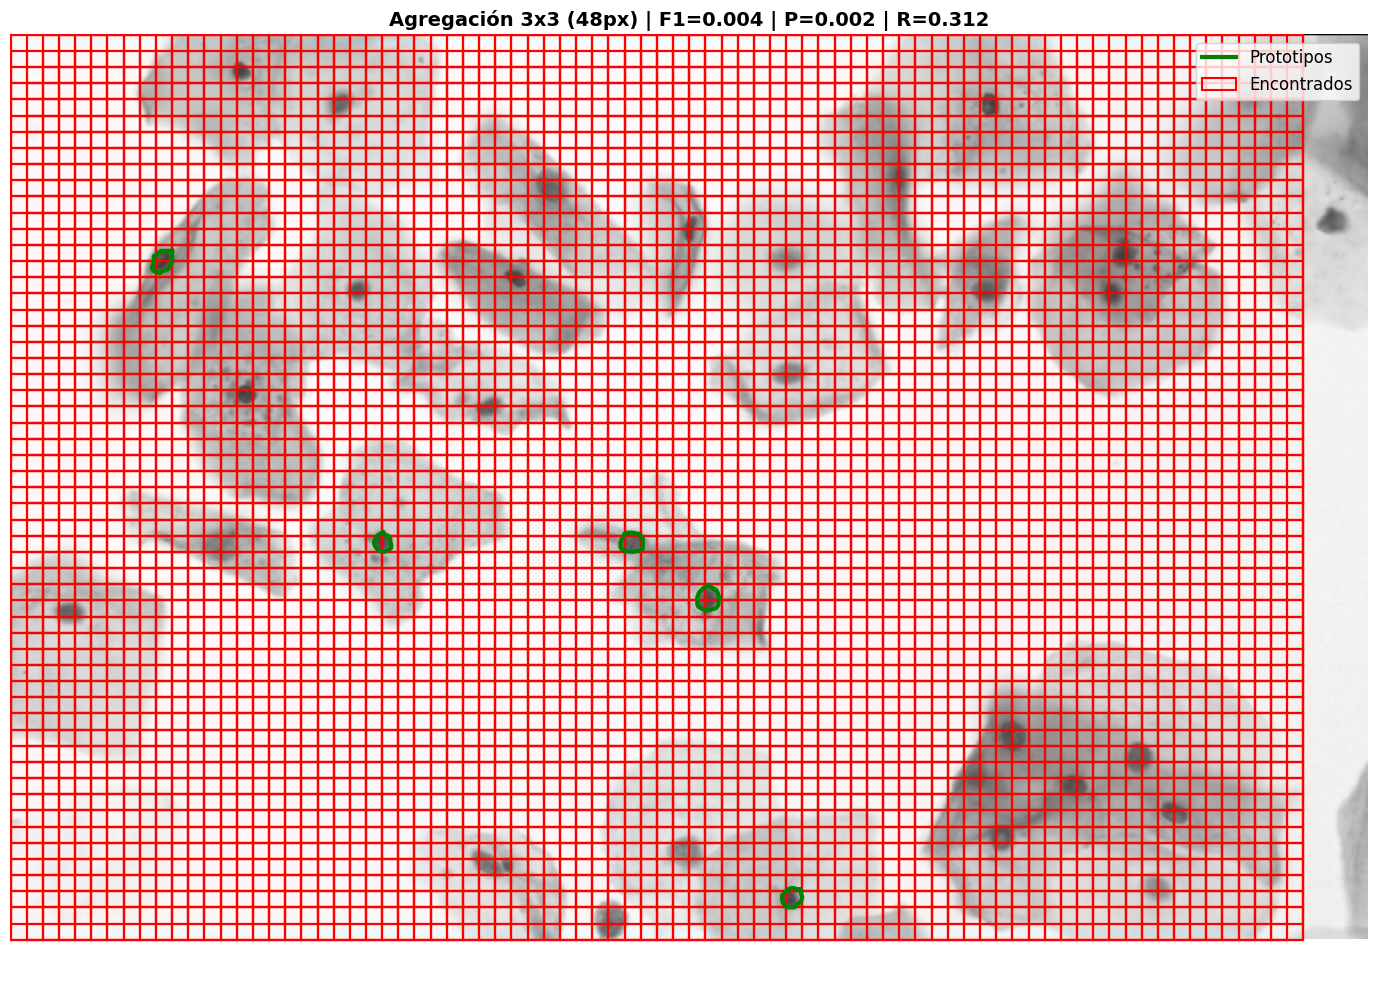


──────────────────────────────────────────────────────────────────────
🔍 NEIGHBORHOOD SIZE = 5x5
   Área cubierta: ~80x80 píxeles
──────────────────────────────────────────────────────────────────────
   Agregando patches...
   ✅ 4476 super-patches creados (de 4480 originales)
   ✅ 5 prototipos válidos
   Patches encontrados: 4455 (99.53%)
   Distancia mínima: 0.0000
   Distancia promedio: 0.0136

   📊 MÉTRICAS:
      TP: 0, FP: 4455, FN: 32
      Precision: 0.000
      Recall: 0.000
      F1-Score: 0.000

──────────────────────────────────────────────────────────────────────
🔍 NEIGHBORHOOD SIZE = 7x7
   Área cubierta: ~112x112 píxeles
──────────────────────────────────────────────────────────────────────
   Agregando patches...
   ✅ 4468 super-patches creados (de 4480 originales)
   ✅ 5 prototipos válidos
   Patches encontrados: 4464 (99.91%)
   Distancia mínima: 0.0000
   Distancia promedio: 0.0092

   📊 MÉTRICAS:
      TP: 0, FP: 4464, FN: 32
      Precision: 0.000
      Recall: 0.

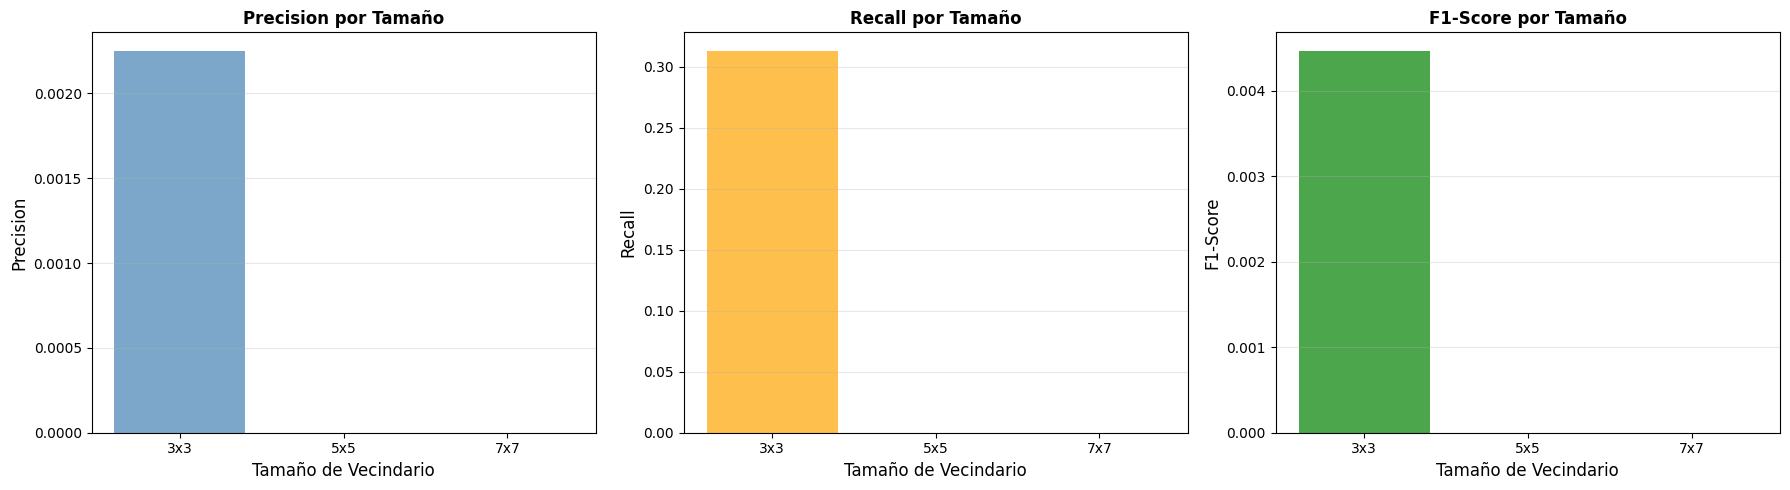


✅ Análisis de agregación completado


In [8]:
# CELDA 5: BÚSQUEDA CON AGREGACIÓN ESPACIAL DE PATCHES

print("="*70)
print("🔍 ANÁLISIS DE TAMAÑOS Y AGREGACIÓN ESPACIAL")
print("="*70)

# Analizar tamaños
x1_sample, y1_sample, x2_sample, y2_sample = patch_data_to_use[0]['position']
patch_size_px = x2_sample - x1_sample
print(f"\n📏 Tamaño actual de patch: {patch_size_px}x{patch_size_px} píxeles")

# Tamaño de núcleos
nucleus_sizes = []
for seg in segmentations:
    coords = np.array(seg['polygon_coords'])
    if len(coords) >= 3:
        x_min, y_min = coords.min(axis=0)
        x_max, y_max = coords.max(axis=0)
        width = x_max - x_min
        height = y_max - y_min
        nucleus_sizes.append((width, height))

if nucleus_sizes:
    nucleus_sizes = np.array(nucleus_sizes)
    avg_nucleus_w = nucleus_sizes.mean(axis=0)[0]
    avg_nucleus_h = nucleus_sizes.mean(axis=0)[1]
    print(f"📏 Tamaño promedio de núcleo: {avg_nucleus_w:.1f}x{avg_nucleus_h:.1f} píxeles")
    print(f"📏 Relación: Un núcleo ≈ {(avg_nucleus_w/patch_size_px):.1f}x{(avg_nucleus_h/patch_size_px):.1f} patches")
    print(f"📏 Área: Un núcleo cubre ~{(avg_nucleus_w/patch_size_px) * (avg_nucleus_h/patch_size_px):.1f} patches")


def create_spatial_aggregated_patches(patch_data, img_shape, neighborhood_size=3):
    """
    Crea super-patches agregando embeddings de vecindarios NxN.
    
    Parameters:
    -----------
    patch_data : list[dict]
        Lista de patches con 'embedding' y 'position'
    img_shape : tuple
        Shape de la imagen (H, W)
    neighborhood_size : int
        Tamaño del vecindario (3 = 3x3 patches, 5 = 5x5, etc.)
    
    Returns:
    --------
    aggregated_patches : list[dict]
        Patches con embeddings agregados y posiciones expandidas
    """
    H, W = img_shape[:2]
    
    # Obtener tamaño de patch
    x1, y1, x2, y2 = patch_data[0]['position']
    patch_px = x2 - x1
    
    # Crear grilla espacial para lookup rápido
    # Mapear (x, y) -> patch_index
    position_to_idx = {}
    for idx, patch in enumerate(patch_data):
        x1, y1, x2, y2 = patch['position']
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        grid_x = cx // patch_px
        grid_y = cy // patch_px
        position_to_idx[(grid_x, grid_y)] = idx
    
    aggregated_patches = []
    
    # Radio del vecindario
    radius = neighborhood_size // 2
    
    for idx, patch in enumerate(patch_data):
        x1, y1, x2, y2 = patch['position']
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        grid_x = cx // patch_px
        grid_y = cy // patch_px
        
        # Recolectar vecinos
        neighbor_embeddings = []
        min_x, max_x = np.inf, -np.inf
        min_y, max_y = np.inf, -np.inf
        
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                neighbor_key = (grid_x + dx, grid_y + dy)
                if neighbor_key in position_to_idx:
                    neighbor_idx = position_to_idx[neighbor_key]
                    neighbor_embeddings.append(patch_data[neighbor_idx]['embedding'])
                    
                    # Actualizar bounding box
                    nx1, ny1, nx2, ny2 = patch_data[neighbor_idx]['position']
                    min_x = min(min_x, nx1)
                    min_y = min(min_y, ny1)
                    max_x = max(max_x, nx2)
                    max_y = max(max_y, ny2)
        
        # Solo agregar si tiene suficientes vecinos
        min_neighbors = max(1, (neighborhood_size * neighborhood_size) // 2)
        if len(neighbor_embeddings) >= min_neighbors:
            # Promediar embeddings del vecindario
            aggregated_emb = np.mean(neighbor_embeddings, axis=0)
            
            aggregated_patches.append({
                'embedding': aggregated_emb,
                'position': (min_x, min_y, max_x, max_y),
                'n_patches': len(neighbor_embeddings)
            })
    
    return aggregated_patches


def buscar_similares_multi_prototipos(embeddings_prototipos, patch_data, threshold, metric='cosine'):
    """
    Busca patches similares a CUALQUIERA de los prototipos (OR lógico).
    Un patch se considera similar si está cerca de al menos un prototipo.
    """
    all_embeddings = np.array([p['embedding'] for p in patch_data])
    
    # Calcular distancias a todos los prototipos
    # Shape: (n_prototipos, n_patches)
    all_distances = cdist(embeddings_prototipos, all_embeddings, metric=metric)
    
    # Para cada patch, tomar la distancia mínima a cualquier prototipo
    min_distances = np.min(all_distances, axis=0)
    
    # Filtrar por threshold
    similar_indices = np.where(min_distances <= threshold)[0]
    
    return similar_indices, min_distances[similar_indices]


# ========== PARÁMETROS ==========
NEIGHBORHOOD_SIZES = [3, 5, 7]  # Probar diferentes tamaños de agregación
N_PROTOTIPOS = 5
MODEL_TO_USE = 'uni'
BEST_THRESHOLD = 0.10  # Usar un threshold razonable

print(f"\n{'='*70}")
print("🎯 PROBANDO DIFERENTES TAMAÑOS DE AGREGACIÓN ESPACIAL")
print(f"{'='*70}\n")

patch_data_source = patch_data_uni if MODEL_TO_USE == 'uni' else patch_data_biomedclip

# Seleccionar prototipos
random.seed(42)
n_prototipos = min(N_PROTOTIPOS, len(segmentations))
prototipos_indices = random.sample(range(len(segmentations)), n_prototipos)
prototipos = [segmentations[i] for i in prototipos_indices]

resultados_agregacion = []

for neighborhood_size in NEIGHBORHOOD_SIZES:
    print(f"\n{'─'*70}")
    print(f"🔍 NEIGHBORHOOD SIZE = {neighborhood_size}x{neighborhood_size}")
    print(f"   Área cubierta: ~{neighborhood_size * patch_size_px}x{neighborhood_size * patch_size_px} píxeles")
    print(f"{'─'*70}")
    
    # Crear patches agregados
    print(f"   Agregando patches...")
    aggregated_patch_data = create_spatial_aggregated_patches(
        patch_data_source, img.shape, neighborhood_size=neighborhood_size
    )
    print(f"   ✅ {len(aggregated_patch_data)} super-patches creados (de {len(patch_data_source)} originales)")
    
    # Calcular embeddings de prototipos con patches agregados
    embeddings_prototipos = []
    for i, proto in enumerate(prototipos):
        emb = get_embedding_for_polygon(proto['polygon_coords'], aggregated_patch_data, img.shape)
        if emb is not None:
            embeddings_prototipos.append(emb)
    
    if len(embeddings_prototipos) == 0:
        print("   ⚠️  No se pudieron extraer embeddings de prototipos")
        continue
    
    print(f"   ✅ {len(embeddings_prototipos)} prototipos válidos")
    
    # Usar estrategia multi-prototipo (OR lógico)
    embeddings_prototipos_array = np.array(embeddings_prototipos)
    
    # Buscar similares
    found_indices, distances = buscar_similares_multi_prototipos(
        embeddings_prototipos_array, aggregated_patch_data, BEST_THRESHOLD
    )
    
    print(f"   Patches encontrados: {len(found_indices)} ({100*len(found_indices)/len(aggregated_patch_data):.2f}%)")
    
    if len(found_indices) > 0:
        print(f"   Distancia mínima: {distances.min():.4f}")
        print(f"   Distancia promedio: {distances.mean():.4f}")
        
        # Calcular métricas
        metricas = calcular_metricas_deteccion(
            found_indices, aggregated_patch_data, segmentations, img.shape, iou_threshold=0.2
        )
        
        print(f"\n   📊 MÉTRICAS:")
        print(f"      TP: {metricas['tp']}, FP: {metricas['fp']}, FN: {metricas['fn']}")
        print(f"      Precision: {metricas['precision']:.3f}")
        print(f"      Recall: {metricas['recall']:.3f}")
        print(f"      F1-Score: {metricas['f1']:.3f}")
        
        resultados_agregacion.append({
            'neighborhood_size': neighborhood_size,
            'n_found': len(found_indices),
            'coverage_px': neighborhood_size * patch_size_px,
            **metricas
        })
        
        # Visualizar solo el mejor
        if len(resultados_agregacion) == 1 or metricas['f1'] > max([r['f1'] for r in resultados_agregacion[:-1]]):
            visualizar_busqueda(
                img, aggregated_patch_data, prototipos, found_indices,
                title=f"Agregación {neighborhood_size}x{neighborhood_size} ({neighborhood_size * patch_size_px}px) | F1={metricas['f1']:.3f} | P={metricas['precision']:.3f} | R={metricas['recall']:.3f}"
            )

# Resumen comparativo
print(f"\n{'='*70}")
print("📊 COMPARACIÓN DE TAMAÑOS DE AGREGACIÓN")
print(f"{'='*70}\n")

print(f"{'Vecindario':<12} {'Tamaño(px)':<12} {'Encontrados':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("─" * 80)

# Agregar resultado original (sin agregación)
print(f"{'1x1':<12} {patch_size_px:<12} {'N/A':<12} {'N/A':<12} {'N/A':<12} {'(ver arriba)':<12}")

for res in resultados_agregacion:
    print(f"{res['neighborhood_size']}x{res['neighborhood_size']:<6} {res['coverage_px']:<12} {res['n_found']:<12} "
          f"{res['precision']:<12.3f} {res['recall']:<12.3f} {res['f1']:<12.3f}")

if resultados_agregacion:
    mejor_res = max(resultados_agregacion, key=lambda x: x['f1'])
    print(f"\n🏆 MEJOR CONFIGURACIÓN: {mejor_res['neighborhood_size']}x{mejor_res['neighborhood_size']} "
          f"({mejor_res['coverage_px']}px) - F1 = {mejor_res['f1']:.3f}")
    
    # Gráfico comparativo
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sizes = [f"{r['neighborhood_size']}x{r['neighborhood_size']}" for r in resultados_agregacion]
    precisions = [r['precision'] for r in resultados_agregacion]
    recalls = [r['recall'] for r in resultados_agregacion]
    f1s = [r['f1'] for r in resultados_agregacion]
    
    axes[0].bar(sizes, precisions, color='steelblue', alpha=0.7)
    axes[0].set_ylabel('Precision', fontsize=12)
    axes[0].set_xlabel('Tamaño de Vecindario', fontsize=12)
    axes[0].set_title('Precision por Tamaño', fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    axes[1].bar(sizes, recalls, color='orange', alpha=0.7)
    axes[1].set_ylabel('Recall', fontsize=12)
    axes[1].set_xlabel('Tamaño de Vecindario', fontsize=12)
    axes[1].set_title('Recall por Tamaño', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    axes[2].bar(sizes, f1s, color='green', alpha=0.7)
    axes[2].set_ylabel('F1-Score', fontsize=12)
    axes[2].set_xlabel('Tamaño de Vecindario', fontsize=12)
    axes[2].set_title('F1-Score por Tamaño', fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

print("\n✅ Análisis de agregación completado")